# Feature Engineering

Create engineered features using `src.feature_engineer.FeatureEngineer` and save the result.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
from src.feature_engineer import FeatureEngineer
from src.data_loader import DataLoader
from src.preprocessing import FraudDataPreprocessor
import pandas as pd

In [2]:
# Load processed fraud data if available, otherwise run preprocessing
processed_path = '../data/processed/fraud_data_processed.csv'
try:
    df = pd.read_csv(processed_path)
    print('Loaded processed data:', processed_path)
except Exception as e:
    print('Processed file not found, loading raw and preprocessing...')
    dl = DataLoader(data_dir='../data/raw')
    fraud_df = dl.load_fraud_data('Fraud_Data.csv')
    ip_df = dl.load_ip_country_data('IpAddress_to_Country.csv')
    prep = FraudDataPreprocessor()
    fraud_clean = prep.clean_data(fraud_df)
    fraud_features = prep.create_time_features(fraud_clean)
    df = prep.merge_with_ip_data(fraud_features, ip_df)
    df.to_csv(processed_path, index=False)
    print('Saved processed data to', processed_path)

Loaded processed data: ../data/processed/fraud_data_processed.csv


In [3]:
# Run feature engineering
fe = FeatureEngineer()
df_ts = df.copy()
# Ensure purchase_time is datetime
if 'purchase_time' in df_ts.columns:
    df_ts['purchase_time'] = pd.to_datetime(df_ts['purchase_time'])
df_features = fe.create_all_features(df_ts)
print('Engineered features shape:', df_features.shape)
df_features.head()

# Validate that required Task 1 features exist
required_feats = ['hour_of_day','day_of_week','time_since_signup','txn_count_24h','avg_time_between_txn_hours']
missing = [f for f in required_feats if f not in df_features.columns]
if missing:
    print('Missing required features:', missing)
else:
    print('All required Task 1 features are present ✅')

# Quick class distribution check (if 'class' exists)
if 'class' in df_features.columns:
    print('Class distribution:\n', df_features['class'].value_counts())

# Save features (already saved later) and notify
print('Features ready; saved step follows in next cell.')

Added transaction frequency and velocity features
Created 10 new features
Engineered features shape: (151112, 28)
All required Task 1 features are present ✅
Class distribution:
 class
0    136961
1     14151
Name: count, dtype: int64
Features ready; saved step follows in next cell.


In [4]:
# Save engineered features
out_path = '../data/processed/fraud_data_features.csv'
df_features.to_csv(out_path, index=False)
print('Saved engineered features to', out_path)

Saved engineered features to ../data/processed/fraud_data_features.csv


In [5]:
# Data transformation: scaling numerical features and one-hot encoding categoricals
from src.preprocessing import FraudDataPreprocessor
import numpy as np
import pandas as pd

prep = FraudDataPreprocessor()
df_trans = df_features.copy()

# Select columns to scale (if present)
num_cols = [c for c in ['purchase_value','txn_count_24h','txn_count_168h','txn_count_720h','avg_time_between_txn_hours','time_since_signup'] if c in df_trans.columns]
if num_cols:
    df_trans = prep.scale_numerical_features(df_trans, num_cols, scaler_type='standard')

# One-hot encode categorical columns for modeling
cat_cols = [c for c in ['country','source','browser'] if c in df_trans.columns]
if cat_cols:
    df_trans = prep.one_hot_encode(df_trans, cat_cols, drop_first=True)

print('Transformed shape:', df_trans.shape)
print('Scaled cols added:', [f'{c}_scaled' for c in num_cols])
print('One-hot encoded columns present:', [c for c in df_trans.columns if any(c.startswith(col+'_') for col in cat_cols)])

# Save transformed dataset for modeling
out_path = '../data/processed/fraud_data_features_transformed.csv'
df_trans.to_csv(out_path, index=False)
print('Saved transformed features to', out_path)

Scaled purchase_value using standard scaler
Scaled txn_count_24h using standard scaler
Scaled txn_count_168h using standard scaler
Scaled txn_count_720h using standard scaler
Scaled avg_time_between_txn_hours using standard scaler
Scaled time_since_signup using standard scaler


One-hot encoded columns: ['source', 'browser']
Transformed shape: (151112, 38)
Scaled cols added: ['purchase_value_scaled', 'txn_count_24h_scaled', 'txn_count_168h_scaled', 'txn_count_720h_scaled', 'avg_time_between_txn_hours_scaled', 'time_since_signup_scaled']
One-hot encoded columns present: ['source_encoded', 'browser_encoded', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari']
Saved transformed features to ../data/processed/fraud_data_features_transformed.csv


In [6]:
# Persist preprocessing artifacts (scalers and encoders) for model training
import os
import joblib

os.makedirs('../models', exist_ok=True)
paths = {}
if hasattr(prep, 'scalers') and prep.scalers:
    scaler_path = '../models/scalers.pkl'
    joblib.dump(prep.scalers, scaler_path)
    paths['scalers'] = scaler_path
    print(f'Saved scalers to {scaler_path}')
else:
    print('No scalers present in current preprocessor instance')

if hasattr(prep, 'encoders') and prep.encoders:
    enc_path = '../models/encoders.pkl'
    joblib.dump(prep.encoders, enc_path)
    paths['encoders'] = enc_path
    print(f'Saved encoders to {enc_path}')
else:
    print('No encoders present in current preprocessor instance')

print('Saved artifact paths:', paths)

Saved scalers to ../models/scalers.pkl
No encoders present in current preprocessor instance
Saved artifact paths: {'scalers': '../models/scalers.pkl'}


In [7]:
# Resampling template (train-only) with before/after logging and optional fallback
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt

if 'class' in df_trans.columns:
    X = df_trans.drop(columns=['class'])
    y = df_trans['class']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
    print('Train class distribution before resampling:', Counter(y_train))

    try:
        from imblearn.over_sampling import SMOTE
        sm = SMOTE(random_state=42)
        X_train_num = X_train.select_dtypes(include=[np.number]).fillna(0)
        X_res, y_res = sm.fit_resample(X_train_num, y_train)
        print('Train class distribution after SMOTE:', Counter(y_res))

        # Save plots
        plt.figure()
        pd.Series(y_train).value_counts().sort_index().plot(kind='bar')
        plt.title('Train class distribution BEFORE SMOTE')
        plt.savefig('../reports/figures/fraud_class_before_smote.png')
        plt.close()

        plt.figure()
        pd.Series(y_res).value_counts().sort_index().plot(kind='bar')
        plt.title('Train class distribution AFTER SMOTE')
        plt.savefig('../reports/figures/fraud_class_after_smote.png')
        plt.close()

    except Exception as e:
        print('SMOTE not available or failed:', e)
        print('\nTo run resampling locally:')
        print("1) pip install imbalanced-learn\n2) Re-run this cell to generate resampled training data and saved plots.")
else:
    print('No `class` column present; cannot demonstrate resampling here.')

Train class distribution before resampling: Counter({0: 102721, 1: 10613})
Train class distribution after SMOTE: Counter({0: 102721, 1: 102721})


In [8]:
# Add additional engineered features
print("Adding additional features...")

# Interaction features
df_features['purchase_value_per_txn_24h'] = df_features['purchase_value'] / (df_features['txn_count_24h'] + 1)
df_features['txn_velocity'] = df_features['txn_count_24h'] / (df_features['time_since_signup'] + 1)
df_features['high_value_flag'] = (df_features['purchase_value'] > df_features['purchase_value'].quantile(0.95)).astype(int)
df_features['recent_activity_flag'] = (df_features['txn_count_24h'] > df_features['txn_count_24h'].quantile(0.75)).astype(int)

# Time-based aggregations
df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)
df_features['is_business_hour'] = ((df_features['hour_of_day'] >= 9) & (df_features['hour_of_day'] <= 17)).astype(int)

print(f"Added 6 additional features. New shape: {df_features.shape}")

# Update saved file
df_features.to_csv('../data/processed/fraud_data_features.csv', index=False)
print("Updated features saved.")

Adding additional features...
Added 6 additional features. New shape: (151112, 34)
Updated features saved.


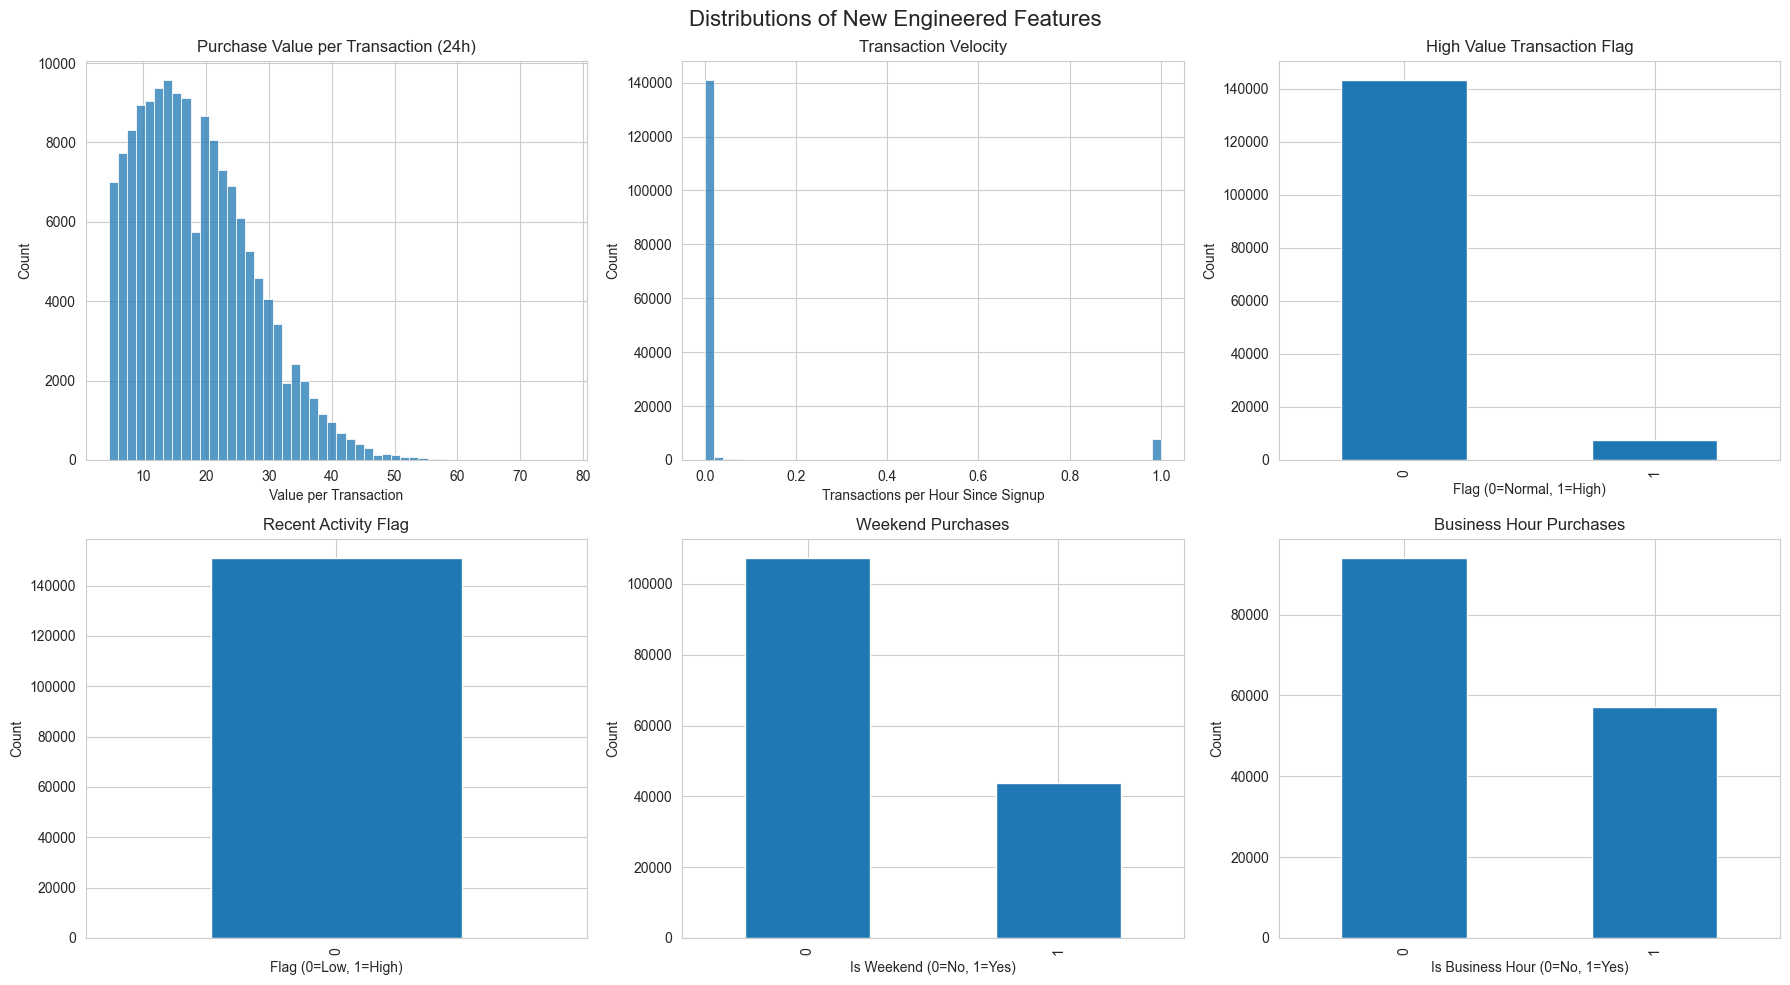

Visualizations saved to ../reports/figures/new_features_distributions.png


In [9]:
# Visualize new features
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create subplots for new features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of New Engineered Features', fontsize=16)

# Purchase value per txn
sns.histplot(df_features['purchase_value_per_txn_24h'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Purchase Value per Transaction (24h)')
axes[0,0].set_xlabel('Value per Transaction')

# Transaction velocity
sns.histplot(df_features['txn_velocity'], bins=50, ax=axes[0,1])
axes[0,1].set_title('Transaction Velocity')
axes[0,1].set_xlabel('Transactions per Hour Since Signup')

# High value flag
df_features['high_value_flag'].value_counts().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('High Value Transaction Flag')
axes[0,2].set_xlabel('Flag (0=Normal, 1=High)')
axes[0,2].set_ylabel('Count')

# Recent activity flag
df_features['recent_activity_flag'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Recent Activity Flag')
axes[1,0].set_xlabel('Flag (0=Low, 1=High)')
axes[1,0].set_ylabel('Count')

# Weekend purchases
df_features['is_weekend'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Weekend Purchases')
axes[1,1].set_xlabel('Is Weekend (0=No, 1=Yes)')
axes[1,1].set_ylabel('Count')

# Business hour purchases
df_features['is_business_hour'].value_counts().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Business Hour Purchases')
axes[1,2].set_xlabel('Is Business Hour (0=No, 1=Yes)')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/figures/new_features_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved to ../reports/figures/new_features_distributions.png")

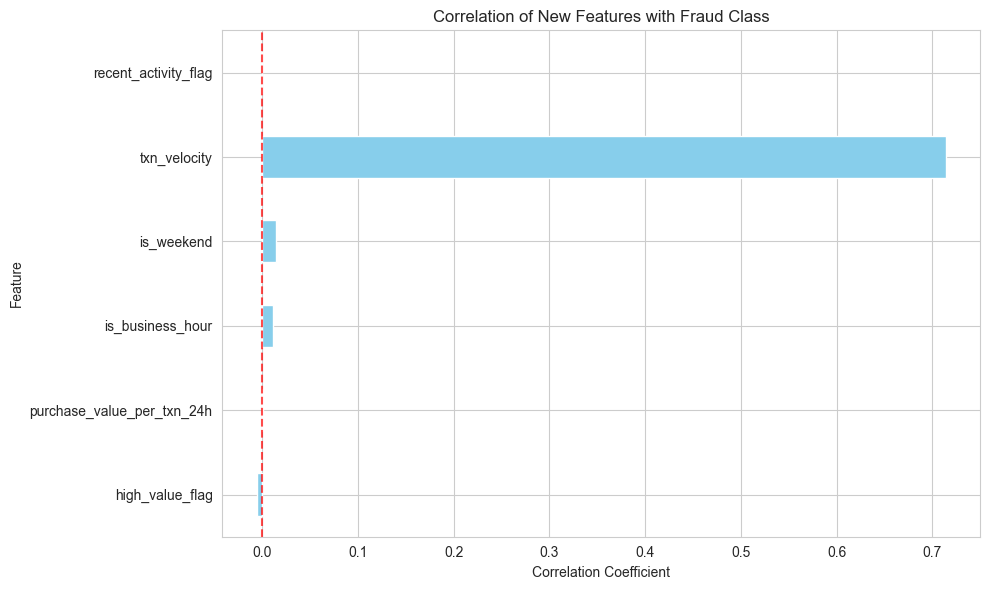

Correlation plot saved to ../reports/figures/new_features_correlation.png
Top correlated features:
txn_velocity                  0.713760
is_weekend                    0.014139
is_business_hour              0.011178
high_value_flag               0.005604
purchase_value_per_txn_24h    0.001011
Name: class, dtype: float64


In [10]:
# Correlation analysis of new features with target
if 'class' in df_features.columns:
    new_features = ['purchase_value_per_txn_24h', 'txn_velocity', 'high_value_flag', 
                   'recent_activity_flag', 'is_weekend', 'is_business_hour']
    
    corr_with_target = df_features[new_features + ['class']].corr()['class'].drop('class')
    
    plt.figure(figsize=(10, 6))
    corr_with_target.sort_values().plot(kind='barh', color='skyblue')
    plt.title('Correlation of New Features with Fraud Class')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Feature')
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('../reports/figures/new_features_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Correlation plot saved to ../reports/figures/new_features_correlation.png")
    print("Top correlated features:")
    print(corr_with_target.abs().sort_values(ascending=False).head())
else:
    print("No 'class' column available for correlation analysis.")

In [11]:
# Add additional engineered features
print("Adding additional features...")

# Interaction features
df_features['purchase_value_per_txn_24h'] = df_features['purchase_value'] / (df_features['txn_count_24h'] + 1)
df_features['txn_velocity'] = df_features['txn_count_24h'] / (df_features['time_since_signup'] + 1)
df_features['high_value_flag'] = (df_features['purchase_value'] > df_features['purchase_value'].quantile(0.95)).astype(int)
df_features['recent_activity_flag'] = (df_features['txn_count_24h'] > df_features['txn_count_24h'].quantile(0.75)).astype(int)

# Time-based aggregations
df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)
df_features['is_business_hour'] = ((df_features['hour_of_day'] >= 9) & (df_features['hour_of_day'] <= 17)).astype(int)

print(f"Added 6 additional features. New shape: {df_features.shape}")

# Update saved file
df_features.to_csv('../data/processed/fraud_data_features.csv', index=False)
print("Updated features saved.")

Adding additional features...
Added 6 additional features. New shape: (151112, 34)
Updated features saved.


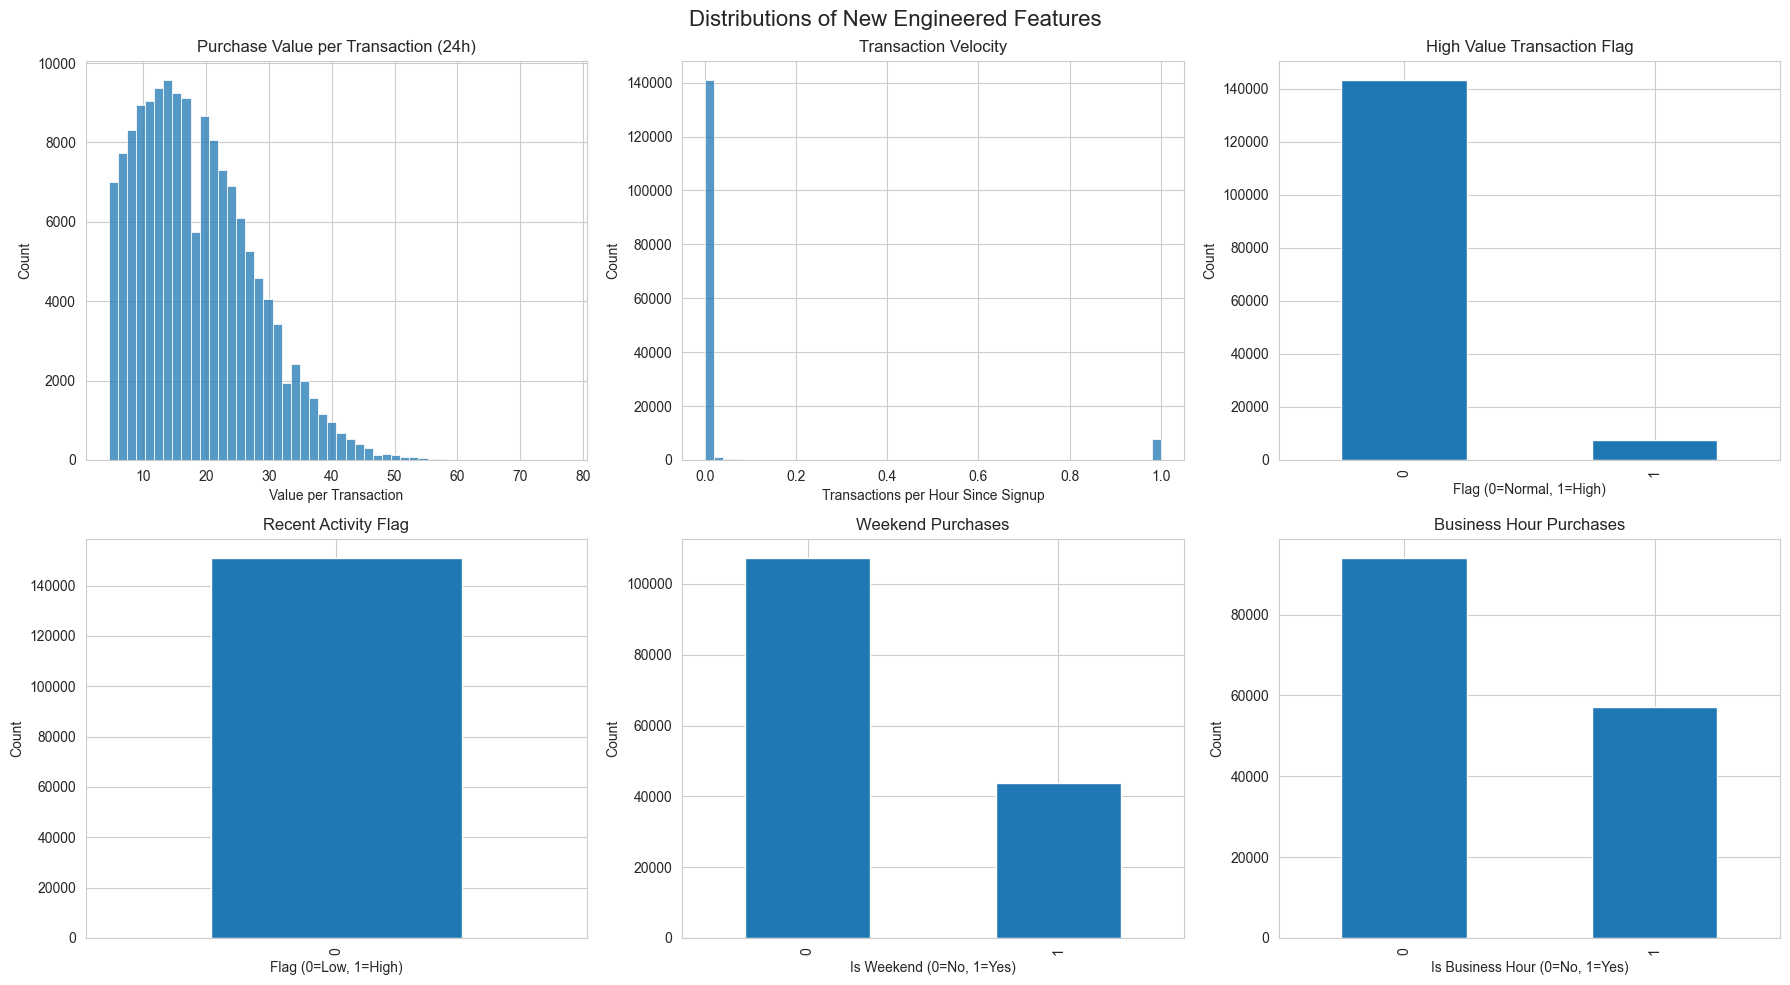

Visualizations saved to ../reports/figures/new_features_distributions.png


In [12]:
# Visualize new features
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create subplots for new features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of New Engineered Features', fontsize=16)

# Purchase value per txn
sns.histplot(df_features['purchase_value_per_txn_24h'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Purchase Value per Transaction (24h)')
axes[0,0].set_xlabel('Value per Transaction')

# Transaction velocity
sns.histplot(df_features['txn_velocity'], bins=50, ax=axes[0,1])
axes[0,1].set_title('Transaction Velocity')
axes[0,1].set_xlabel('Transactions per Hour Since Signup')

# High value flag
df_features['high_value_flag'].value_counts().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('High Value Transaction Flag')
axes[0,2].set_xlabel('Flag (0=Normal, 1=High)')
axes[0,2].set_ylabel('Count')

# Recent activity flag
df_features['recent_activity_flag'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Recent Activity Flag')
axes[1,0].set_xlabel('Flag (0=Low, 1=High)')
axes[1,0].set_ylabel('Count')

# Weekend purchases
df_features['is_weekend'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Weekend Purchases')
axes[1,1].set_xlabel('Is Weekend (0=No, 1=Yes)')
axes[1,1].set_ylabel('Count')

# Business hour purchases
df_features['is_business_hour'].value_counts().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Business Hour Purchases')
axes[1,2].set_xlabel('Is Business Hour (0=No, 1=Yes)')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/figures/new_features_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved to ../reports/figures/new_features_distributions.png")

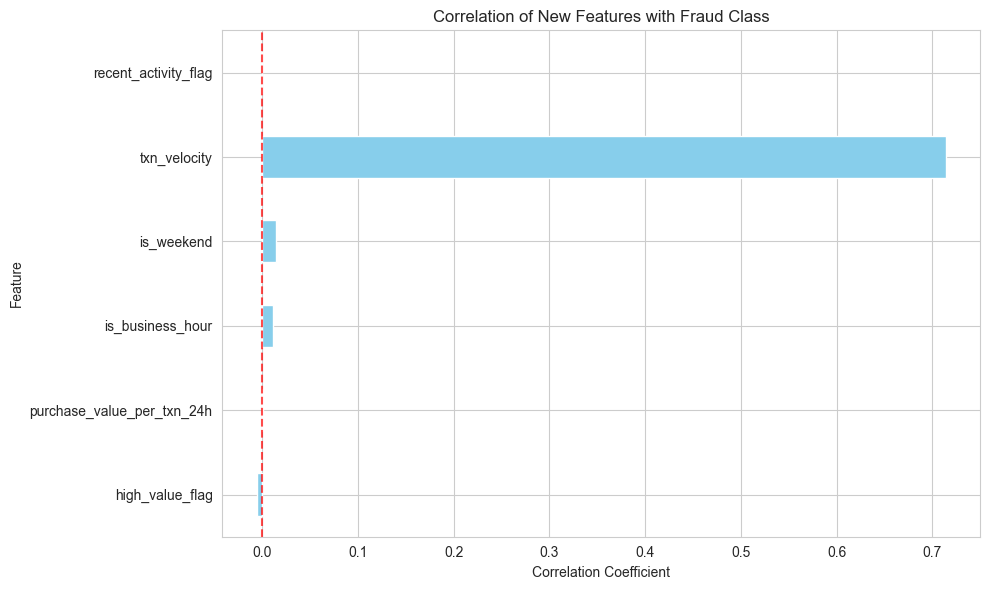

Correlation plot saved to ../reports/figures/new_features_correlation.png
Top correlated features:
txn_velocity                  0.713760
is_weekend                    0.014139
is_business_hour              0.011178
high_value_flag               0.005604
purchase_value_per_txn_24h    0.001011
Name: class, dtype: float64


In [13]:
# Correlation analysis of new features with target
if 'class' in df_features.columns:
    new_features = ['purchase_value_per_txn_24h', 'txn_velocity', 'high_value_flag', 
                   'recent_activity_flag', 'is_weekend', 'is_business_hour']
    
    corr_with_target = df_features[new_features + ['class']].corr()['class'].drop('class')
    
    plt.figure(figsize=(10, 6))
    corr_with_target.sort_values().plot(kind='barh', color='skyblue')
    plt.title('Correlation of New Features with Fraud Class')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Feature')
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('../reports/figures/new_features_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Correlation plot saved to ../reports/figures/new_features_correlation.png")
    print("Top correlated features:")
    print(corr_with_target.abs().sort_values(ascending=False).head())
else:
    print("No 'class' column available for correlation analysis.")